In [65]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [66]:
df = pd.read_csv("cleaned_ai_models.csv")

Linear Regression

In [67]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

data = df.copy()
open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

print("Value counts of 'Openness' immediately after creation (Linear Regression block):")
print(data['Openness'].value_counts())
print(f"Number of models with Openness == 2: {data[data['Openness'] == 2].shape[0]}")

data['log_compute'] = np.log10(data['Training compute (FLOP)'])
data['log_params'] = np.log10(data['Parameters'])

data['Year'] = pd.to_datetime(data['Publication date']).dt.year

data = data[data['Year'] >= 2010]

data['Frontier model'] = data['Frontier model'].astype(int)
data['Foundation model'] = data['Foundation model'].astype(int)

X = data[['log_compute',
          'log_params',
          'Year',
          'Frontier model',
          'Foundation model']]

X = sm.add_constant(X)

y = data['Openness']

temp_df = pd.concat([X, y], axis=1).dropna()

X_final = temp_df[X.columns]
y_final = temp_df['Openness']

model = sm.OLS(y_final, X_final)
ols_result = model.fit()

print(ols_result.summary())

Value counts of 'Openness' immediately after creation (Linear Regression block):
Openness
0    1759
1     978
2     500
Name: count, dtype: int64
Number of models with Openness == 2: 500
                            OLS Regression Results                            
Dep. Variable:               Openness   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     19.78
Date:                Mon, 11 May 2026   Prob (F-statistic):           5.90e-19
Time:                        03:00:52   Log-Likelihood:                -1228.8
No. Observations:                1158   AIC:                             2470.
Df Residuals:                    1152   BIC:                             2500.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       

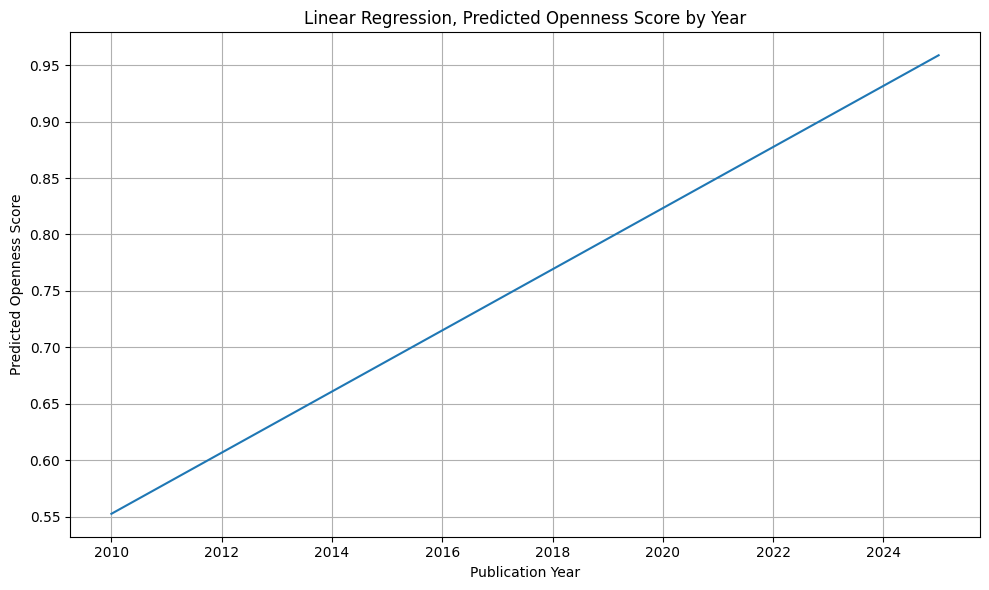

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

year_min_lr = int(X_final['Year'].min())
year_max_lr = int(X_final['Year'].max())
year_range_lr = np.linspace(year_min_lr, year_max_lr, 100)

predict_df_lr = pd.DataFrame({
    'const': 1,
    'log_compute': X_final['log_compute'].mean(),
    'log_params': X_final['log_params'].mean(),
    'Year': year_range_lr,
    'Frontier model': X_final['Frontier model'].mode()[0],
    'Foundation model': X_final['Foundation model'].mode()[0]
}, columns=X_final.columns)

predicted_openness_score_lr = ols_result.predict(predict_df_lr)

plt.figure(figsize=(10, 6))
sns.lineplot(x=year_range_lr, y=predicted_openness_score_lr)
plt.title('Linear Regression, Predicted Openness Score by Year')
plt.xlabel('Publication Year')
plt.ylabel('Predicted Openness Score')
plt.grid(True)
plt.tight_layout()
plt.show()

Logistic Regression

In [69]:
y = df['Open model weights?']

In [70]:
log_compute = np.log(df['Training compute (FLOP)'])
log_params = np.log(df['Parameters'])

df['Year'] = pd.to_datetime(df['Publication date']).dt.year

In [71]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)
training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

print("Value counts of 'Openness' immediately after creation:")
print(data['Openness'].value_counts())

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log(data['Parameters_clean'])

data['Year'] = pd.to_datetime(data['Publication date'], errors='coerce').dt.year
data['Year'] = data['Year'].fillna(data['Year'].median())

data['Frontier model'] = data['Frontier model'].astype(int)
data['Foundation model'] = data['Foundation model'].astype(int)

X = data[['log_compute',
          'log_params',
          'Year',
          'Frontier model',
          'Foundation model']]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

y = data['Openness']


temp_df = pd.concat([X, y.rename('target_variable')], axis=1)

temp_df = temp_df.dropna()

y_final = temp_df['target_variable']
X_final = temp_df.drop(columns='target_variable')

print("Value counts of 'Openness' (ternary) in y_final after data preparation:")
print(y_final.value_counts())

model = sm.MNLogit(y_final, X_final)
mnlogit_result = model.fit()

print(mnlogit_result.summary())

Value counts of 'Openness' immediately after creation:
Openness
0    1759
1     978
2     500
Name: count, dtype: int64
Value counts of 'Openness' (ternary) in y_final after data preparation:
target_variable
0    1759
1     978
2     500
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.932378
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:        target_variable   No. Observations:                 3237
Model:                        MNLogit   Df Residuals:                     3225
Method:                           MLE   Df Model:                           10
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.05010
Time:                        03:00:52   Log-Likelihood:                -3018.1
converged:                       True   LL-Null:                       -3177.3
Covariance Type:            nonrobust   LLR p-value:                 2.054e-62
ta

#### Linear Regression: Predicted Openness Score by Year

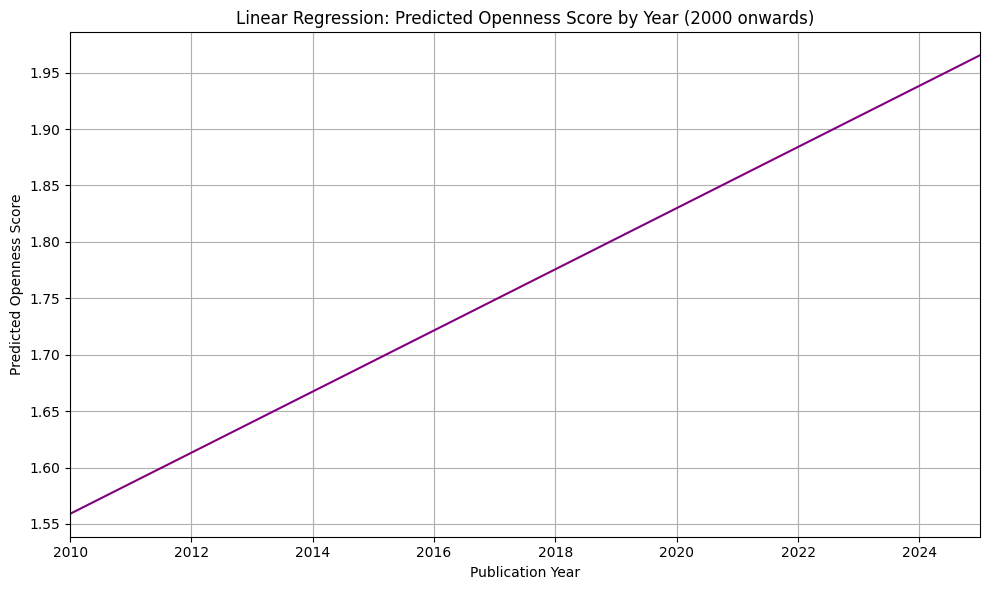

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

year_min_lr = 2010
year_max_lr = int(X_final['Year'].max())
year_range_lr = np.linspace(year_min_lr, year_max_lr, 100)

predict_df_lr = pd.DataFrame({
    'const': 1,
    'log_compute': X_final['log_compute'].mean(),
    'log_params': X_final['log_params'].mean(),
    'Year': year_range_lr,
    'Frontier model': X_final['Frontier model'].mode()[0],
    'Foundation model': X_final['Foundation model'].mode()[0]
}, columns=X_final.columns)

predicted_openness_score_lr = ols_result.predict(predict_df_lr)

plt.figure(figsize=(10, 6))
sns.lineplot(x=year_range_lr, y=predicted_openness_score_lr, color='purple')
plt.title('Linear Regression: Predicted Openness Score by Year (2000 onwards)')
plt.xlabel('Publication Year')
plt.ylabel('Predicted Openness Score')
plt.grid(True)
plt.xlim(year_min_lr, year_max_lr)
plt.tight_layout()
plt.show()

#### Multinomial Logistic Regression: Predicted Probabilities by Year

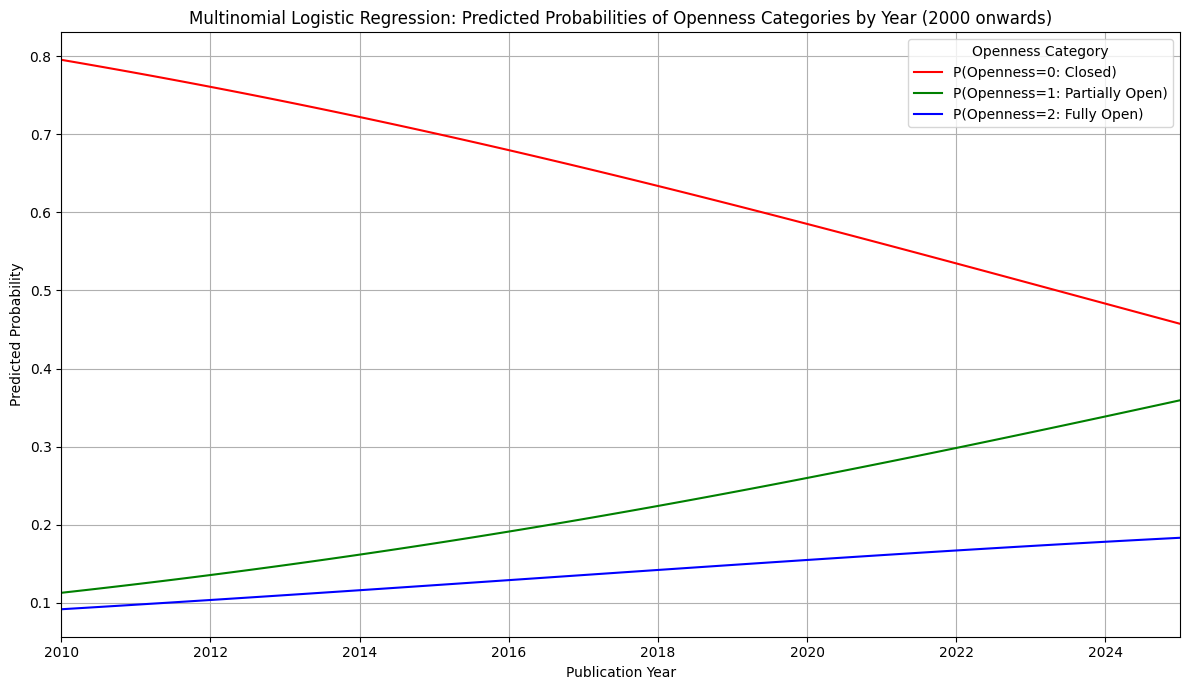

In [73]:
year_min_mnlogit = 2010
year_max_mnlogit = int(X_final['Year'].max())
year_range_mnlogit = np.linspace(year_min_mnlogit, year_max_mnlogit, 100)

predict_df_mnlogit = pd.DataFrame({
    'const': 1,
    'log_compute': X_final['log_compute'].mean(),
    'log_params': X_final['log_params'].mean(),
    'Year': year_range_mnlogit,
    'Frontier model': X_final['Frontier model'].mode()[0],
    'Foundation model': X_final['Foundation model'].mode()[0]
}, columns=X_final.columns)

predicted_probs_mnlogit = mnlogit_result.predict(predict_df_mnlogit)

plt.figure(figsize=(12, 7))
sns.lineplot(x=year_range_mnlogit, y=predicted_probs_mnlogit[0], label='P(Openness=0: Closed)', color='red')
sns.lineplot(x=year_range_mnlogit, y=predicted_probs_mnlogit[1], label='P(Openness=1: Partially Open)', color='green')
sns.lineplot(x=year_range_mnlogit, y=predicted_probs_mnlogit[2], label='P(Openness=2: Fully Open)', color='blue')

plt.title('Multinomial Logistic Regression: Predicted Probabilities of Openness Categories by Year (2000 onwards)')
plt.xlabel('Publication Year')
plt.ylabel('Predicted Probability')
plt.legend(title='Openness Category')
plt.grid(True)
plt.xlim(year_min_mnlogit, year_max_mnlogit)
plt.tight_layout()
plt.show()

In [74]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = X_final
y = y_final

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gb)
report = classification_report(y_test, y_pred_gb)

print(f"Gradient Boosting Model Accuracy: {accuracy:.4f}")
print("\nGradient Boosting Classification Report:")
print(report)

Gradient Boosting Model Accuracy: 0.6420

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       375
           1       0.50      0.55      0.52       188
           2       0.41      0.14      0.21        85

    accuracy                           0.64       648
   macro avg       0.55      0.50      0.50       648
weighted avg       0.62      0.64      0.62       648



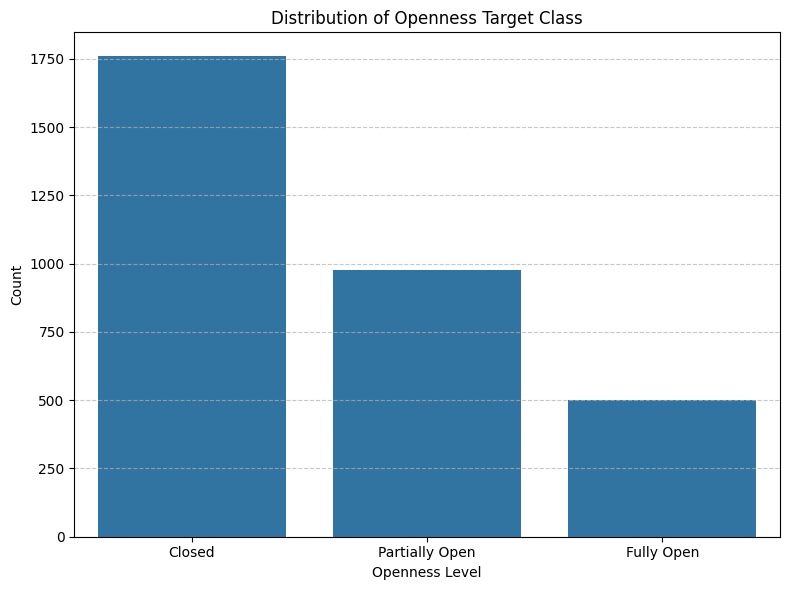

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_final)
plt.title('Distribution of Openness Target Class')
plt.xlabel('Openness Level')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9]
}

gb_classifier = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_classifier,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

best_params = grid_search.best_params_

final_gb_model = GradientBoostingClassifier(
    random_state=42,
    **best_params
)

final_gb_model.fit(X_train, y_train)

y_pred_final_gb = final_gb_model.predict(X_test)

final_accuracy_gb = accuracy_score(y_test, y_pred_final_gb)
final_report_gb = classification_report(y_test, y_pred_final_gb)

print(f"Final Gradient Boosting Model Accuracy (with best parameters): {final_accuracy_gb:.4f}")
print("\nFinal Gradient Boosting Classification Report (with best parameters):")
print(final_report_gb)

### Random Forest Classifier

Let's train a Random Forest classifier using the same `X_train`, `X_test`, `y_train`, and `y_test` splits and compare its performance to the XGBoost model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:")
print(rf_report)

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

X = X_final
y = y_final

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_report = classification_report(y_test, y_pred_dt)

print(f"Decision Tree Model Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(dt_report)

In [ ]:
print('--- Gradient Boosting Classification Report (Optimized) ---\n', final_report_gb)
print('\n--- Random Forest Classification Report ---\n', rf_report)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ['Gradient Boosting (Optimized)', 'Random Forest']
accuracies = [final_accuracy_gb, rf_accuracy]

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='Accuracy', data=accuracy_df, hue='Model', legend=False, palette='viridis')
plt.title('Model Accuracy Comparison')

min_acc = accuracy_df['Accuracy'].min()
max_acc = accuracy_df['Accuracy'].max()

lower_limit = max(0.5, min_acc - 0.05)
upper_limit = max_acc + 0.05

plt.ylim(lower_limit, upper_limit)
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [ ]:
print("Gradient Boosting Feature Importance:")
for i, col in enumerate(X_final.columns):
    print(f"  {col}: {final_gb_model.feature_importances_[i]:.4f}")

print("\nRandom Forest Feature Importance:")
for i, col in enumerate(X_final.columns):
    print(f"  {col}: {rf_model.feature_importances_[i]:.4f}")

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log(data['Parameters_clean'])

data['Year'] = pd.to_datetime(data['Publication date'], errors='coerce').dt.year
data['Year'] = data['Year'].fillna(data['Year'].median())

data['Frontier model'] = data['Frontier model'].astype(int)
data['Foundation model'] = data['Foundation model'].astype(int)

X = data[['log_compute',
          'log_params',
          'Year',
          'Frontier model',
          'Foundation model']]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

y = data['Openness']

temp_df = pd.concat([X, y.rename('target_variable')], axis=1)
temp_df = temp_df.dropna()
y_final = temp_df['target_variable']
X_final = temp_df.drop(columns='target_variable')

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

best_params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}

final_gb_model = GradientBoostingClassifier(
    random_state=42,
    **best_params
)

final_gb_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

years_in_test_set = sorted(X_test['Year'].unique())

yearly_gb_accuracies = []
yearly_rf_accuracies = []

for year in years_in_test_set:
    X_test_year = X_test[X_test['Year'] == year]
    y_test_year = y_test[X_test['Year'] == year]

    if not X_test_year.empty:
        y_pred_gb_year = final_gb_model.predict(X_test_year)
        gb_accuracy_year = accuracy_score(y_test_year, y_pred_gb_year)
        yearly_gb_accuracies.append({'Year': year, 'Model': 'Gradient Boosting', 'Accuracy': gb_accuracy_year})

        y_pred_rf_year = rf_model.predict(X_test_year)
        rf_accuracy_year = accuracy_score(y_test_year, y_pred_rf_year)
        yearly_rf_accuracies.append({'Year': year, 'Model': 'Random Forest', 'Accuracy': rf_accuracy_year})

yearly_performance_df = pd.DataFrame(yearly_gb_accuracies + yearly_rf_accuracies)

yearly_performance_df_filtered = yearly_performance_df[yearly_performance_df['Year'] >= 2000]

plt.figure(figsize=(14, 8))

gb_data = yearly_performance_df_filtered[yearly_performance_df_filtered['Model'] == 'Gradient Boosting']
rf_data = yearly_performance_df_filtered[yearly_performance_df_filtered['Model'] == 'Random Forest']

sns.lineplot(
    data=gb_data,
    x='Year',
    y='Accuracy',
    color='blue',
    marker='o',
    markersize=8,
    linewidth=2.5,
    label='Gradient Boosting'
)

sns.lineplot(
    data=rf_data,
    x='Year',
    y='Accuracy',
    color='orange',
    marker='o',
    markersize=8,
    linewidth=1.5,
    label='Random Forest'
)

plt.title('Model Accuracy Per Year on Test Set (2000 onwards)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.xlim(yearly_performance_df_filtered['Year'].min() - 0.5, yearly_performance_df_filtered['Year'].max() + 0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model', fontsize=10, title_fontsize=12, loc='best')
plt.tight_layout()
plt.show()

In [ ]:
mean_accuracy_since_2000 = yearly_performance_df[yearly_performance_df['Year'] >= 2000].groupby('Model')['Accuracy'].mean().reset_index()
print("Mean Accuracy Since 2000:")
print(mean_accuracy_since_2000)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

mean_log_compute = X_final['log_compute'].mean()
mean_log_params = X_final['log_params'].mean()
mean_year = X_final['Year'].mean()

scenarios = []
labels = []

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 0, 0])
labels.append('Not Frontier, Not Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 0, 1])
labels.append('Not Frontier, Is Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 1, 0])
labels.append('Is Frontier, Not Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 1, 1])
labels.append('Is Frontier, Is Foundation')

predict_df_gb = pd.DataFrame(scenarios, columns=X_final.columns)

predicted_probs_gb = final_gb_model.predict_proba(predict_df_gb)

plot_data_gb = pd.DataFrame(predicted_probs_gb, columns=['P(Closed)', 'P(Partially Open)', 'P(Fully Open)'])
plot_data_gb['Scenario'] = labels

plot_data_gb_melted = plot_data_gb.melt(id_vars='Scenario', var_name='Openness Category', value_name='Probability')

plt.figure(figsize=(12, 7))
sns.barplot(x='Scenario', y='Probability', hue='Openness Category', data=plot_data_gb_melted, palette='viridis')
plt.title('Gradient Boosting: Predicted Openness Probabilities by Frontier & Foundation Status')
plt.xlabel('Model Type Scenario')
plt.ylabel('Predicted Probability')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Openness Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

mean_log_compute = X_final['log_compute'].mean()
mean_log_params = X_final['log_params'].mean()
mean_year = X_final['Year'].mean()

scenarios = []
labels = []

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 0, 0])
labels.append('Not Frontier, Not Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 0, 1])
labels.append('Not Frontier, Is Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 1, 0])
labels.append('Is Frontier, Not Foundation')

scenarios.append([1, mean_log_compute, mean_log_params, mean_year, 1, 1])
labels.append('Is Frontier, Is Foundation')

predict_df_rf = pd.DataFrame(scenarios, columns=X_final.columns)

predicted_probs_rf = rf_model.predict_proba(predict_df_rf)

plot_data_rf = pd.DataFrame(predicted_probs_rf, columns=['P(Closed)', 'P(Partially Open)', 'P(Fully Open)'])
plot_data_rf['Scenario'] = labels

plot_data_rf_melted = plot_data_rf.melt(id_vars='Scenario', var_name='Openness Category', value_name='Probability')

plt.figure(figsize=(12, 7))
sns.barplot(x='Scenario', y='Probability', hue='Openness Category', data=plot_data_rf_melted, palette='magma')
plt.title('Random Forest: Predicted Openness Probabilities by Frontier & Foundation Status')
plt.xlabel('Model Type Scenario')
plt.ylabel('Predicted Probability')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Openness Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Year'] = pd.to_datetime(data['Publication date'], errors='coerce').dt.year
data['Year'] = data['Year'].fillna(data['Year'].median())

data['Frontier model'] = data['Frontier model'].astype(int)
data['Foundation model'] = data['Foundation model'].astype(int)

data_filtered = data[data['Year'] >= 2000].dropna(subset=['Openness', 'Year', 'Frontier model', 'Foundation model'])

frontier_openness = data_filtered[data_filtered['Frontier model'] == 1].groupby('Year')['Openness'].mean().reset_index()
frontier_openness['Model Type'] = 'Frontier Model'

foundation_openness = data_filtered[data_filtered['Foundation model'] == 1].groupby('Year')['Openness'].mean().reset_index()
foundation_openness['Model Type'] = 'Foundation Model'

combined_openness_trend = pd.concat([frontier_openness, foundation_openness])

plt.figure(figsize=(14, 8))
sns.lineplot(x='Year', y='Openness', hue='Model Type', data=combined_openness_trend, marker='o', palette={'Frontier Model': 'red', 'Foundation Model': 'blue'})
plt.title('Average Openness Over Time: Frontier vs. Foundation Models', fontsize=16)
plt.xlabel('Publication Year', fontsize=12)
plt.ylabel('Average Openness Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Model Type')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


import numpy as np

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data_plot = data.dropna(subset=['log_compute', 'Openness']).copy()

data_plot['Openness_Category'] = data_plot['Openness'].map({0: 'Closed', 1: 'Partially Open', 2: 'Fully Open'})

plt.figure(figsize=(10, 7))

sns.lineplot(x='log_compute', y='Openness', data=data_plot, color='blue', linewidth=2)
plt.title('Log10(Training Compute) vs. Openness')
plt.xlabel('Log10(Training Compute (FLOP))')
plt.ylabel('Average Openness (0=Closed, 1=Partial, 2=Full)')
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'])
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data_plot = data.dropna(subset=['log_compute', 'log_params', 'Openness']).copy()

data_plot['Openness_Category'] = data_plot['Openness'].map({0: 'Closed', 1: 'Partially Open', 2: 'Fully Open'})

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(x='log_compute', y='Openness', hue='Openness_Category', data=data_plot, palette='viridis', alpha=0.6, s=50)
sns.regplot(x='log_compute', y='Openness', data=data_plot, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Log10(Training Compute) vs. Openness')
plt.xlabel('Log10(Training Compute (FLOP))')
plt.ylabel('Openness (0=Closed, 1=Partial, 2=Full)')
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Openness Level')

plt.subplot(1, 2, 2)
sns.scatterplot(x='log_params', y='Openness', hue='Openness_Category', data=data_plot, palette='viridis', alpha=0.6, s=50)
sns.regplot(x='log_params', y='Openness', data=data_plot, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Log10(Parameters) vs. Openness')
plt.xlabel('Log10(Parameters)')
plt.ylabel('Openness (0=Closed, 1=Partial, 2=Full)')
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Openness Level')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data_plot = data.dropna(subset=['log_compute', 'Openness']).copy()

min_log_compute = data_plot['log_compute'].min()
max_log_compute = data_plot['log_compute'].max()

num_bins = 26
bins = np.linspace(min_log_compute, max_log_compute, num_bins + 1)
labels = (bins[:-1] + bins[1:]) / 2

data_plot['log_compute_binned'] = pd.cut(data_plot['log_compute'], bins=bins, labels=labels, include_lowest=True)

aggregated_data = data_plot.groupby('log_compute_binned', observed=False)['Openness'].mean().reset_index()
aggregated_data['log_compute_binned'] = pd.to_numeric(aggregated_data['log_compute_binned'])

plt.figure(figsize=(12, 8))

sns.lineplot(
    x='log_compute_binned',
    y='Openness',
    data=aggregated_data,
    color='blue',
    linewidth=2,
    marker='o',
    errorbar=None,
    label='Average Openness (Binned)'
)

if 'model_data_df' in globals() and not model_data_df.empty:
    model_colors = plt.cm.viridis(np.linspace(0, 1, len(model_data_df['Model'].unique())))
    color_map = dict(zip(model_data_df['Model'].unique(), model_colors))

    sns.scatterplot(
        x='log_compute',
        y='Openness',
        data=model_data_df,
        hue='Model',
        s=200,
        palette=color_map,
        edgecolor='black',
        zorder=5
    )

plt.title('Log10(Training Compute) vs. Average Openness with Specific Models', fontsize=16)
plt.xlabel('Log10(Training Compute (FLOP)) - Binned Midpoint', fontsize=12)
plt.ylabel('Average Openness (0=Closed, 1=Partial, 2=Full)', fontsize=12)
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'], fontsize=10)
plt.xticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Openness / Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

### Log10(Training Compute) vs. Openness, colored by Log10(Parameters)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data_plot = data.dropna(subset=['log_compute', 'log_params', 'Openness']).copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='log_compute',
    y='Openness',
    hue='log_params',
    data=data_plot,
    palette='viridis',
    size='log_params',
    sizes=(20, 400),
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Log10(Training Compute) vs. Openness (Colored by Log10(Parameters))', fontsize=16)
plt.xlabel('Log10(Training Compute (FLOP))', fontsize=12)
plt.ylabel('Openness (0=Closed, 1=Partial, 2=Full)', fontsize=12)
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'], fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Log10(Parameters)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

### Log10(Parameters) vs. Openness

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data_plot = data.dropna(subset=['log_params', 'Openness']).copy()

min_log_params = data_plot['log_params'].min()
max_log_params = data_plot['log_params'].max()

num_bins = 14
bins = np.linspace(min_log_params, max_log_params, num_bins + 1)
labels = (bins[:-1] + bins[1:]) / 2

data_plot['log_params_binned'] = pd.cut(data_plot['log_params'], bins=bins, labels=labels, include_lowest=True)

aggregated_data = data_plot.groupby('log_params_binned', observed=False)['Openness'].mean().reset_index()
aggregated_data['log_params_binned'] = pd.to_numeric(aggregated_data['log_params_binned'])

plt.figure(figsize=(12, 8))

sns.lineplot(
    x='log_params_binned',
    y='Openness',
    data=aggregated_data,
    color='blue',
    linewidth=2,
    marker='o',
    errorbar=None,
    label='Average Openness (Binned)'
)

if 'model_data_df' in globals() and not model_data_df.empty:
    model_colors = plt.cm.viridis(np.linspace(0, 1, len(model_data_df['Model'].unique())))
    color_map = dict(zip(model_data_df['Model'].unique(), model_colors))

    sns.scatterplot(
        x='log_params',
        y='Openness',
        data=model_data_df,
        hue='Model',
        s=200,
        palette=color_map,
        edgecolor='black',
        zorder=5
    )

plt.title('Log10(Parameters) vs. Average Openness (Binned) with Specific Models', fontsize=16)
plt.xlabel('Log10(Parameters) - Binned Midpoint', fontsize=12)
plt.ylabel('Average Openness (0=Closed, 1=Partial, 2=Full)', fontsize=12)
plt.yticks(ticks=[0, 1, 2], labels=['Closed', 'Partially Open', 'Fully Open'], fontsize=10)
plt.xticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Openness / Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
specific_models = [
    'GPT-2',
    'LLaMA',
    'BLOOM',
    'OLMo-7B',
    'GPT-5',
    'Gemini 3.1'
]

model_data_for_plot = []

df = pd.read_csv("cleaned_ai_models.csv")

data = df.copy()

open_weights_binary = data['Open model weights?'].map({'Yes': 1, 'No': 0}).fillna(0)

training_code_binary = data['Training code accessibility'].map({
    'Fully open': 1,
    'Open access to parts of the code base': 1,
    'Open access to some of the code base': 1,
    'Open source': 1,
    'Open (non-commercial)': 1,
    'Open (restricted use)': 1,
    'Not applicable (e.g. not a ML model)': 0,
    'Closed (proprietary)': 0,
    'NA': 0,
    'Unreleased': 0
}).fillna(0)

data['Openness'] = 0
data.loc[(open_weights_binary == 1) | (training_code_binary == 1), 'Openness'] = 1
data.loc[(open_weights_binary == 1) & (training_code_binary == 1), 'Openness'] = 2

data['Training compute (FLOP)_clean'] = data['Training compute (FLOP)'].replace(0, 1).fillna(data['Training compute (FLOP)'].median())
data['Parameters_clean'] = data['Parameters'].replace(0, 1).fillna(data['Parameters'].median())

data['log_compute'] = np.log10(data['Training compute (FLOP)_clean'])
data['log_params'] = np.log10(data['Parameters_clean'])

data['Year'] = pd.to_datetime(data['Publication date'], errors='coerce').dt.year
data['Year'] = data['Year'].fillna(data['Year'].median())

data['Model_Cleaned'] = data['Model'].str.strip().str.lower().str.replace('\n', '', regex=False)

print("Searching for specific model data for plotting:")
for model_name in specific_models:
    model_search_name = model_name.strip().lower().replace('\n', '')

    matching_models = pd.DataFrame()

    if model_name == 'GPT-2':
        matching_models = data[data['Model_Cleaned'].str.contains(r'gpt-?2', na=False)]
    elif model_name in ['LLaMA', 'BLOOM', 'OLMo-7B']:
        matching_models = data[data['Model_Cleaned'].str.contains(model_search_name, na=False)]
    else:
        matching_models = data[data['Model_Cleaned'] == model_search_name]

    if not matching_models.empty:
        for index, matched_model in matching_models.iterrows():
            log_param_val = matched_model['log_params']
            openness_val = matched_model['Openness']
            year_val = matched_model['Year']

            if model_name == 'GPT-2':
                year_val = 2019
            elif model_name == 'LLaMA' or model_name == 'BLOOM':
                year_val = 2023
            elif model_name == 'OLMo-7B':
                year_val = 2024
            elif model_name == 'GPT-5':
                year_val = 2025

            model_data_for_plot.append({
                'Model': model_name,
                'log_params': log_param_val,
                'Openness': openness_val,
                'Year': year_val,
                'Original_Model_Name': matched_model['Model']
            })
    else:
        print(f"  {model_name}: Not found in dataset.")

raw_model_data_df = pd.DataFrame(model_data_for_plot)

if not raw_model_data_df.empty:
    model_data_df = raw_model_data_df.groupby('Model').agg({
        'log_params': 'mean',
        'Openness': 'mean',
        'Year': 'mean',
        'Original_Model_Name': lambda x: ', '.join(x.unique())
    }).reset_index()
else:
    model_data_df = pd.DataFrame()

print("\nModel data collected and aggregated for plotting (mean values):")
if not model_data_df.empty:
    display(model_data_df)
else:
    print("No specific models found in the dataset for plotting.")